In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
from transforms import radon
from utils import load_checkpoint
from torchdiffeq import odeint
import time
from torch import optim
from torchmetrics import CatMetric
from unet import Unet
import copy
from tqdm import tqdm
import math

/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
torch.manual_seed(159753)
np.random.seed(159753)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
# %%capture
im_size = 64
problem = "circles"
checkpoint_path = f'problems/{problem}/checkpoints/{im_size}x{im_size}-v2/ckp_7938.tar'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
method = "euler"

# this channel parameter needs to match whatever model you are actually loading
model = Unet(ch=32).to(device)

step, epoch, model, _, _, _ = load_checkpoint(checkpoint_path, model)

model.eval()

Unet(
  (input_proj): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResBlock(
        (skip_connection): Identity()
        (block1): Sequential(
          (0): GroupNorm(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Identity()
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (block2): Sequential(
          (0): GroupNorm(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (cond_block): ConditioningBlock(
          (proj): Sequential(
            (0): SiLU()
            (1): Linear(in_features=128, out_features=64, bias=True)


In [4]:
from typing import Callable, Dict, List, Optional

from torch import autocast
from torchdiffeq import odeint_adjoint 
import torch.nn as nn

def inverse_loss_fn(x, y):
    """
    Loss function for the inverse problem.
    """
    device = x.device
    if isinstance(x, np.ndarray):
        x= torch.tensor(x, device=device, dtype=torch.float32)
    if isinstance(y, np.ndarray):
        y = torch.tensor(y, device=device, dtype=torch.float32)

    x = x.float()
    y = y.float()


    loss = torch.mean((x - y) ** 2)

    return loss
    
def ode_integrate(ode_func: nn.Module,
                  init_x: torch.Tensor,
                  ode_opts: Dict = {},
                  t_eps: float = 0,
                  init_t: float = 0.,
                  final_t: float = 1.,
                  t_arr: Optional[List[float]] = None,
                  num_steps: int = 5,
                  intermediate_points: bool = False,
                  method: str = "euler"
      ) -> torch.Tensor:

    if t_arr is None:
        t = torch.linspace(init_t - t_eps, final_t, num_steps).to(init_x.device)
    else:
        t = torch.tensor(t_arr, dtype=torch.float32, device=init_x.device)

    ode_opts = {
        "atol": 1e-5,
        "rtol": 1e-5,
        "method": method,
        **ode_opts
    }

    z = odeint(
        func = lambda t, x: ode_func(x, t.expand(x.shape[0])),
        y0 = init_x,
        t = t,
        **ode_opts
    )

    if not intermediate_points:
        return z[-1]
    return z


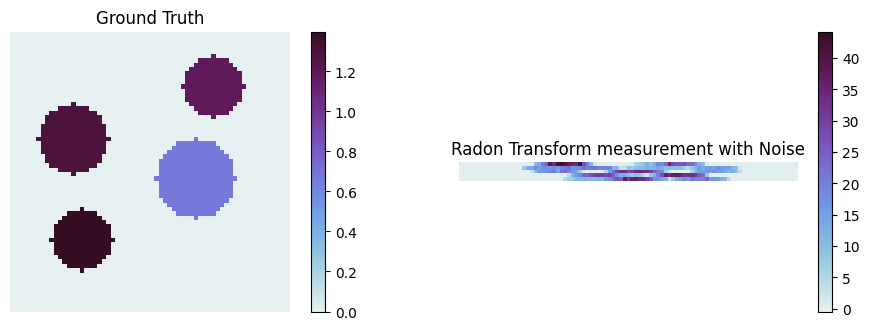

In [5]:
# load data and select a random ground truth from test set
test_data = torch.load(f'data/{problem}-dataset-{im_size}.pt')["test"]
idx = np.random.randint(0, len(test_data))
gt = test_data[idx].to(device).unsqueeze(0)

# apply radon transform, and apply multiplicative noise
img_radon = radon.radon_transform(gt.squeeze().cpu().numpy(), N=5)
img_radon = torch.tensor(img_radon, device=device, dtype=torch.float32).unsqueeze(0)
img_radon = img_radon.unsqueeze(0)  # add batch dimension   

# mult noise
img_radon = (1 + 0.1 * torch.randn_like(img_radon)) * img_radon
# plot gt, plot img_radon, plot initial guess in x_0 space, and plot flow realization
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(gt.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
plt.title('Ground Truth')
plt.axis('off')
plt.colorbar()
plt.subplot(2, 2, 2)
plt.imshow(img_radon.squeeze().cpu().numpy(), cmap=cmocean.cm.dense)
plt.title('Radon Transform measurement with Noise')
plt.axis('off')
plt.colorbar()

In [6]:
# getting normalization constants
train_min, train_max = torch.min(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"]), torch.max(torch.load(f'data/{problem}-dataset-{im_size}.pt')["train"])

In [7]:
from torch.func import vmap, jvp, vjp
def sketch_jacobian(oversampling_param: int,
                    sketch_dim: int,
                    jac_dim: int,
                    model: nn.Module,
                    ode_integrate: Callable,
                    x0: torch.Tensor,
                    num_steps: int = 5,
                    intermediate_points: bool = False,
                    chunk_size: int = 8,
                    method: str = "euler"
                    ) -> torch.Tensor:
    # rangefinder step
    ell = sketch_dim + oversampling_param
    x0_detached = x0.detach().clone().requires_grad_(False)
    # we sample images of shape im_size x im_size and we compute jacobian vector products via jvp, then convert the outputs to vectors
    # those vectors are the columns of Y
    # we use jvp to form Y but we can easily also use finite difference
    def f(x_):
        x1 = ode_integrate(model, x_, num_steps=num_steps, intermediate_points=intermediate_points, method=method)
        # unnormalize
        x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
        return x1
        
    # we can do some vectorizing here using vmap
    Y = torch.zeros(jac_dim, ell).to(x0_detached.device)

    def single_jvp(omega):
        return jvp(f, (x0_detached,), (omega.unsqueeze(0),))[1].view(im_size*im_size)

    with torch.no_grad():
        omegas = torch.randn(ell, 1, im_size, im_size, device=x0.device)
        Y = vmap(single_jvp, chunk_size=8)(omegas).T  # shape: (jac_dim, ell)
        # compute QR 
        Q_range, _ = torch.linalg.qr(Y, mode='reduced')
        del Y, omegas

    with torch.no_grad():
        _, vjp_fn = vjp(f, x0_detached)
        Q_out = Q_range.reshape(im_size * im_size, ell)
        # transpose and reshape to images to pass into f
        Q_out_imgs = Q_out.T.reshape(ell, *f(x0_detached).shape)

        def apply_vjp(v_cotangent):
            # this should reshape back to a vector
            return vjp_fn(v_cotangent)[0].reshape(-1)

        # todo: probably need to make this dynamic
        B = vmap(apply_vjp, chunk_size=8)(Q_out_imgs)

        U_tilde, S, Vh = torch.linalg.svd(B, full_matrices=False)
        del B, Q_out_imgs
        U = Q_range @ U_tilde
        torch.cuda.empty_cache() if x0.device.type == 'cuda' else None
    return U, S, Vh


In [ ]:
num_steps = 5
intermediate_points = False
sketch_dim = math.floor(im_size * im_size * .025)
oversampling_param = 0
jac_dim = im_size * im_size
y = img_radon.clone().to(device)
x0 = torch.randn((1, 1, im_size, im_size), device=device, dtype=torch.float32)
x0 = x0.requires_grad_()

x1 = ode_integrate(model, x0, num_steps=5, intermediate_points=False, method=method)
x1 = 0.5 * (x1 + 1.0) * (train_max - train_min) + train_min
# apply forward operator, << I'm not adding noise here
x1_radon = radon.radon_transform(x1, N=5)
loss = inverse_loss_fn(x1_radon, y)

In [9]:
%%timeit
grad = torch.autograd.grad(loss, x0, create_graph=True)[0]

173 ms ± 2.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
%%timeit
U, S, Vh = sketch_jacobian(oversampling_param, sketch_dim, jac_dim, model,
ode_integrate, x0, num_steps=num_steps, intermediate_points=intermediate_points)

9.95 s ± 17.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
